In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
DATA_PATH = '/content/'

In [5]:
videos_df = pd.read_csv(
    DATA_PATH + 'USvideos.csv',
    encoding='utf-8'
)
category_json = pd.read_json(
    DATA_PATH + 'US_category_id.json'
)

In [12]:
print("SHAPE:")
print(videos_df.shape)
print("\nFIRST 5 ROWS:")
print(videos_df.head())
print("\nMISSING VALUES:")
print(videos_df.isnull().sum())
print("\nDUPLICATE ROWS:")
print(videos_df.duplicated().sum())
print("\nCOLUMN NAMES:")
print(videos_df.columns.tolist())
print("\nDATA TYPES:")
print(videos_df.dtypes)

SHAPE:
(40949, 16)

FIRST 5 ROWS:
      video_id trending_date  \
0  2kyS6SvSYSE      17.14.11   
1  1ZAPwfrtAFY      17.14.11   
2  5qpjK5DgCt4      17.14.11   
3  puqaWrEC7tY      17.14.11   
4  d380meD0W0M      17.14.11   

                                               title          channel_title  \
0                 WE WANT TO TALK ABOUT OUR MARRIAGE           CaseyNeistat   
1  The Trump Presidency: Last Week Tonight with J...        LastWeekTonight   
2  Racist Superman | Rudy Mancuso, King Bach & Le...           Rudy Mancuso   
3                   Nickelback Lyrics: Real or Fake?  Good Mythical Morning   
4                           I Dare You: GOING BALD!?               nigahiga   

   category_id              publish_time  \
0           22  2017-11-13T17:13:01.000Z   
1           24  2017-11-13T07:30:00.000Z   
2           23  2017-11-12T19:05:24.000Z   
3           24  2017-11-13T11:00:04.000Z   
4           24  2017-11-12T18:01:41.000Z   

                                 

In [13]:
print("=" * 60)
print("CATEGORY JSON OVERVIEW")
print("=" * 60)

print(category_json.head())

CATEGORY JSON OVERVIEW
                                kind  \
0  youtube#videoCategoryListResponse   
1  youtube#videoCategoryListResponse   
2  youtube#videoCategoryListResponse   
3  youtube#videoCategoryListResponse   
4  youtube#videoCategoryListResponse   

                                                etag  \
0  "m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...   
1  "m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...   
2  "m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...   
3  "m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...   
4  "m2yskBQFythfE4irbTIeOgYYfBU/S730Ilt-Fi-emsQJv...   

                                               items  
0  {'kind': 'youtube#videoCategory', 'etag': '"m2...  
1  {'kind': 'youtube#videoCategory', 'etag': '"m2...  
2  {'kind': 'youtube#videoCategory', 'etag': '"m2...  
3  {'kind': 'youtube#videoCategory', 'etag': '"m2...  
4  {'kind': 'youtube#videoCategory', 'etag': '"m2...  


In [14]:
category_items = category_json['items']

category_mapping_data = []

for item in category_items:

    category_id = int(item['id'])

    category_name = item['snippet']['title']

    category_mapping_data.append(
        {
            'category_id': category_id,
            'category_name': category_name
        }
    )

category_mapping_df = pd.DataFrame(category_mapping_data)


In [15]:
category_mapping = dict(
    zip(
        category_mapping_df['category_id'],
        category_mapping_df['category_name']
    )
)

In [16]:
videos_df['category_name'] = videos_df['category_id'].map(
    category_mapping
)

print("\nCATEGORY MAPPING SUCCESSFUL")
print(videos_df[['category_id', 'category_name']].head())


CATEGORY MAPPING SUCCESSFUL
   category_id   category_name
0           22  People & Blogs
1           24   Entertainment
2           23          Comedy
3           24   Entertainment
4           24   Entertainment


In [17]:
videos_df = videos_df.drop_duplicates()

In [18]:
videos_df['description'] = videos_df['description'].fillna('No Description')

videos_df['tags'] = videos_df['tags'].fillna('No Tags')

videos_df = videos_df.dropna(
    subset=[
        'title',
        'views',
        'likes',
        'dislikes',
        'comment_count'
    ]
)

In [19]:
numeric_columns = [
    'views',
    'likes',
    'dislikes',
    'comment_count'
]

for column in numeric_columns:

    videos_df[column] = pd.to_numeric(
        videos_df[column],
        errors='coerce'
    )

In [20]:
videos_df['trending_date'] = pd.to_datetime(
    videos_df['trending_date'],
    format='%y.%d.%m'
)

In [21]:
videos_df['publish_time'] = pd.to_datetime(
    videos_df['publish_time']
)

In [22]:
videos_df = videos_df.sort_values(
    by='trending_date'
)

videos_df = videos_df.drop_duplicates(
    subset='video_id',
    keep='first'
)

print("\nDATASET SHAPE AFTER KEEPING FIRST TREND:")
print(videos_df.shape)


DATASET SHAPE AFTER KEEPING FIRST TREND:
(6351, 17)


In [23]:
videos_df['title'] = videos_df['title'].str.strip()

videos_df['channel_title'] = videos_df['channel_title'].str.strip()

In [24]:
videos_df['engagement_rate'] = (
    (
        videos_df['likes']
        + videos_df['dislikes']
        + videos_df['comment_count']
    )
    / videos_df['views']
) * 100

In [25]:
videos_df['like_rate'] = (
    videos_df['likes']
    / videos_df['views']
) * 100

In [26]:
videos_df['dislike_rate'] = (
    videos_df['dislikes']
    / videos_df['views']
) * 100

In [29]:
videos_df['trending_date'] = pd.to_datetime(
    videos_df['trending_date'],
    format='%y.%d.%m'
)

In [30]:
videos_df['publish_time'] = pd.to_datetime(
    videos_df['publish_time']
).dt.tz_localize(None)

In [31]:
videos_df['days_to_trend'] = (
    videos_df['trending_date']
    - videos_df['publish_time']
).dt.days

In [32]:
videos_df['publish_weekday'] = videos_df[
    'publish_time'
].dt.day_name()

In [33]:
videos_df['tag_count'] = videos_df['tags'].apply(
    lambda x: len(str(x).split('|'))
)

In [34]:
average_engagement_rate = videos_df['engagement_rate'].mean()

average_like_rate = videos_df['like_rate'].mean()

average_dislike_rate = videos_df['dislike_rate'].mean()

average_days_to_trend = videos_df['days_to_trend'].mean()

In [36]:
print("=" * 60)
print("ENGAGEMENT KPIs")
print("=" * 60)

print(f"\nAverage Engagement Rate: {average_engagement_rate:.2f}%")
print(f"\nAverage Like Rate: {average_like_rate:.2f}%")
print(f"\nAverage Dislike Rate: {average_dislike_rate:.2f}%")
print(f"\nAverage Days to Trend: {average_days_to_trend:.2f} Days")

ENGAGEMENT KPIs

Average Engagement Rate: 4.76%

Average Like Rate: 4.03%

Average Dislike Rate: 0.17%

Average Days to Trend: 21.52 Days


In [37]:
correlation_columns = [
    'views',
    'likes',
    'dislikes',
    'comment_count',
    'engagement_rate',
    'days_to_trend'
]

correlation_matrix = videos_df[
    correlation_columns
].corr()

print("=" * 60)
print("PEARSON CORRELATION MATRIX")
print("=" * 60)

print(correlation_matrix)

PEARSON CORRELATION MATRIX
                    views     likes  dislikes  comment_count  engagement_rate  \
views            1.000000  0.761127  0.396135       0.599628         0.057128   
likes            0.761127  1.000000  0.360274       0.806198         0.318552   
dislikes         0.396135  0.360274  1.000000       0.679838         0.097088   
comment_count    0.599628  0.806198  0.679838       1.000000         0.258414   
engagement_rate  0.057128  0.318552  0.097088       0.258414         1.000000   
days_to_trend   -0.035336 -0.028872 -0.011298      -0.020393        -0.103773   

                 days_to_trend  
views                -0.035336  
likes                -0.028872  
dislikes             -0.011298  
comment_count        -0.020393  
engagement_rate      -0.103773  
days_to_trend         1.000000  


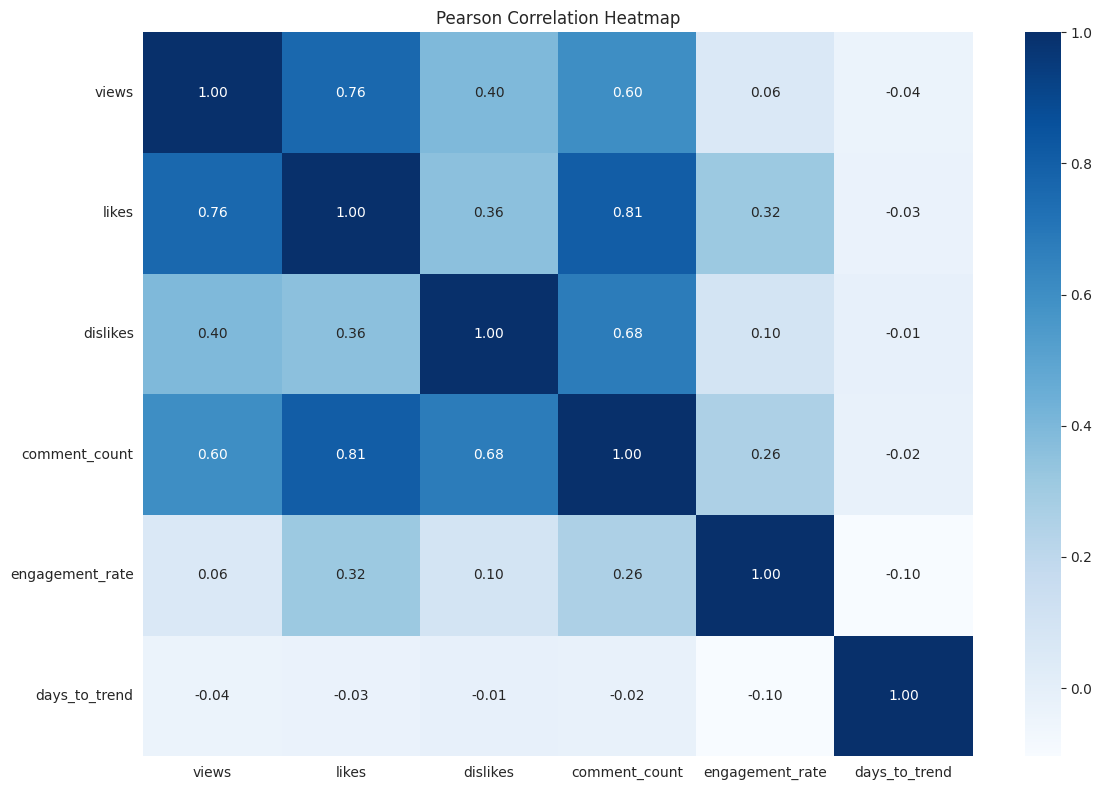

In [38]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Pearson Correlation Heatmap')

plt.tight_layout()

plt.show()

In [39]:
category_metrics = videos_df.groupby(
    'category_name'
).agg({

    'views': 'mean',

    'engagement_rate': 'mean',

    'like_rate': 'mean'

}).reset_index()

category_metrics.columns = [
    'category_name',
    'avg_views',
    'avg_engagement_rate',
    'avg_like_rate'
]

category_metrics = category_metrics.sort_values(
    by='avg_views',
    ascending=False
)

print("=" * 60)
print("CATEGORY METRICS")
print("=" * 60)

print(category_metrics.head())

CATEGORY METRICS
            category_name     avg_views  avg_engagement_rate  avg_like_rate
7                   Music  1.387621e+06             8.234088       7.401756
5                  Gaming  1.211844e+06             5.482981       4.380282
9   Nonprofits & Activism  1.025217e+06             4.830642       3.744533
4        Film & Animation  9.204330e+05             4.029484       3.397430
14                 Sports  8.302815e+05             2.039082       1.611957


In [40]:
highest_engagement_categories = category_metrics.sort_values(
    by='avg_engagement_rate',
    ascending=False
).head(10)

print("\nHIGHEST ENGAGEMENT CATEGORIES:")
print(highest_engagement_categories)


HIGHEST ENGAGEMENT CATEGORIES:
            category_name     avg_views  avg_engagement_rate  avg_like_rate
7                   Music  1.387621e+06             8.234088       7.401756
6           Howto & Style  4.731389e+05             5.974671       5.144877
1                  Comedy  7.729546e+05             5.689227       4.971189
10         People & Blogs  7.127675e+05             5.505346       4.700354
5                  Gaming  1.211844e+06             5.482981       4.380282
11         Pets & Animals  2.801044e+05             5.120998       4.495007
2               Education  3.519795e+05             4.852176       4.181318
9   Nonprofits & Activism  1.025217e+06             4.830642       3.744533
12   Science & Technology  5.843225e+05             4.231290       3.580616
4        Film & Animation  9.204330e+05             4.029484       3.397430


In [41]:
lowest_engagement_categories = category_metrics.sort_values(
    by='avg_engagement_rate',
    ascending=True
).head(10)

print("\nLOWEST ENGAGEMENT CATEGORIES:")
print(lowest_engagement_categories)


LOWEST ENGAGEMENT CATEGORIES:
            category_name     avg_views  avg_engagement_rate  avg_like_rate
14                 Sports  8.302815e+05             2.039082       1.611957
0        Autos & Vehicles  4.063595e+05             2.254111       1.795106
8         News & Politics  2.474269e+05             2.635620       1.448823
15        Travel & Events  2.415110e+05             3.115025       2.561576
13                  Shows  3.923588e+05             3.588949       2.885584
3           Entertainment  8.171242e+05             3.843338       3.204845
4        Film & Animation  9.204330e+05             4.029484       3.397430
12   Science & Technology  5.843225e+05             4.231290       3.580616
9   Nonprofits & Activism  1.025217e+06             4.830642       3.744533
2               Education  3.519795e+05             4.852176       4.181318


In [42]:
highest_view_categories = category_metrics.sort_values(
    by='avg_views',
    ascending=False
).head(10)

print("\nHIGHEST VIEW CATEGORIES:")
print(highest_view_categories)


HIGHEST VIEW CATEGORIES:
            category_name     avg_views  avg_engagement_rate  avg_like_rate
7                   Music  1.387621e+06             8.234088       7.401756
5                  Gaming  1.211844e+06             5.482981       4.380282
9   Nonprofits & Activism  1.025217e+06             4.830642       3.744533
4        Film & Animation  9.204330e+05             4.029484       3.397430
14                 Sports  8.302815e+05             2.039082       1.611957
3           Entertainment  8.171242e+05             3.843338       3.204845
1                  Comedy  7.729546e+05             5.689227       4.971189
10         People & Blogs  7.127675e+05             5.505346       4.700354
12   Science & Technology  5.843225e+05             4.231290       3.580616
6           Howto & Style  4.731389e+05             5.974671       5.144877


In [43]:
overall_avg_views = category_metrics['avg_views'].mean()

overall_avg_engagement = category_metrics[
    'avg_engagement_rate'
].mean()

loyal_but_low_exposure = category_metrics[
    (category_metrics['avg_views'] < overall_avg_views)
    &
    (
        category_metrics['avg_engagement_rate']
        > overall_avg_engagement
    )
]

print("\nLOYAL BUT LOW EXPOSURE CATEGORIES:")
print(loyal_but_low_exposure)


LOYAL BUT LOW EXPOSURE CATEGORIES:
     category_name      avg_views  avg_engagement_rate  avg_like_rate
6    Howto & Style  473138.932773             5.974671       5.144877
2        Education  351979.460000             4.852176       4.181318
11  Pets & Animals  280104.355072             5.120998       4.495007


In [44]:
overall_avg_video_views = videos_df['views'].mean()

overall_avg_video_engagement = videos_df[
    'engagement_rate'
].mean()

passive_audience_videos = videos_df[
    (videos_df['views'] > overall_avg_video_views)
    &
    (
        videos_df['engagement_rate']
        < overall_avg_video_engagement
    )
]

print("\nPASSIVE AUDIENCE VIDEOS:")
print(
    passive_audience_videos[
        [
            'title',
            'category_name',
            'views',
            'engagement_rate'
        ]
    ].head()
)


PASSIVE AUDIENCE VIDEOS:
                                                 title         category_name  \
130          Remy Ma - Wake Me Up (Audio) ft. Lil' Kim                 Music   
148  Thirty Seconds To Mars - Walk On Water (Offici...                 Music   
113                  Google Pixelbook: $1000 of Weird!  Science & Technology   
117           Meryl Streep Meets Anna Wintour at Vogue         Entertainment   
121  Sean Astin Knew Nothing About 'Lord Of The Rin...         Entertainment   

       views  engagement_rate  
130  1231518         3.910377  
148  1905487         3.819811  
113  1575525         3.822028  
117  1017803         2.677728  
121   844653         1.592015  


In [45]:
niche_loyal_audience_videos = videos_df[
    (videos_df['views'] < overall_avg_video_views)
    &
    (
        videos_df['engagement_rate']
        > overall_avg_video_engagement
    )
]

print("\nNICHE LOYAL AUDIENCE VIDEOS:")
print(
    niche_loyal_audience_videos[
        [
            'title',
            'category_name',
            'views',
            'engagement_rate'
        ]
    ].head()
)


NICHE LOYAL AUDIENCE VIDEOS:
                                                 title   category_name  \
0                   WE WANT TO TALK ABOUT OUR MARRIAGE  People & Blogs   
128                 Birthdays - Simon's Cat | GUIDE TO  Pets & Animals   
131               L.A. Noire - Nintendo Switch Trailer          Gaming   
132        Everything I Wore This Week! Outfit Diary 1   Howto & Style   
134  Pitbull, Stereotypes - Jungle (Lyric Video) ft...           Music   

      views  engagement_rate  
0    748374        10.215080  
128  426078         4.814377  
131  154872         6.186399  
132   72626         5.495277  
134  264511         4.918888  


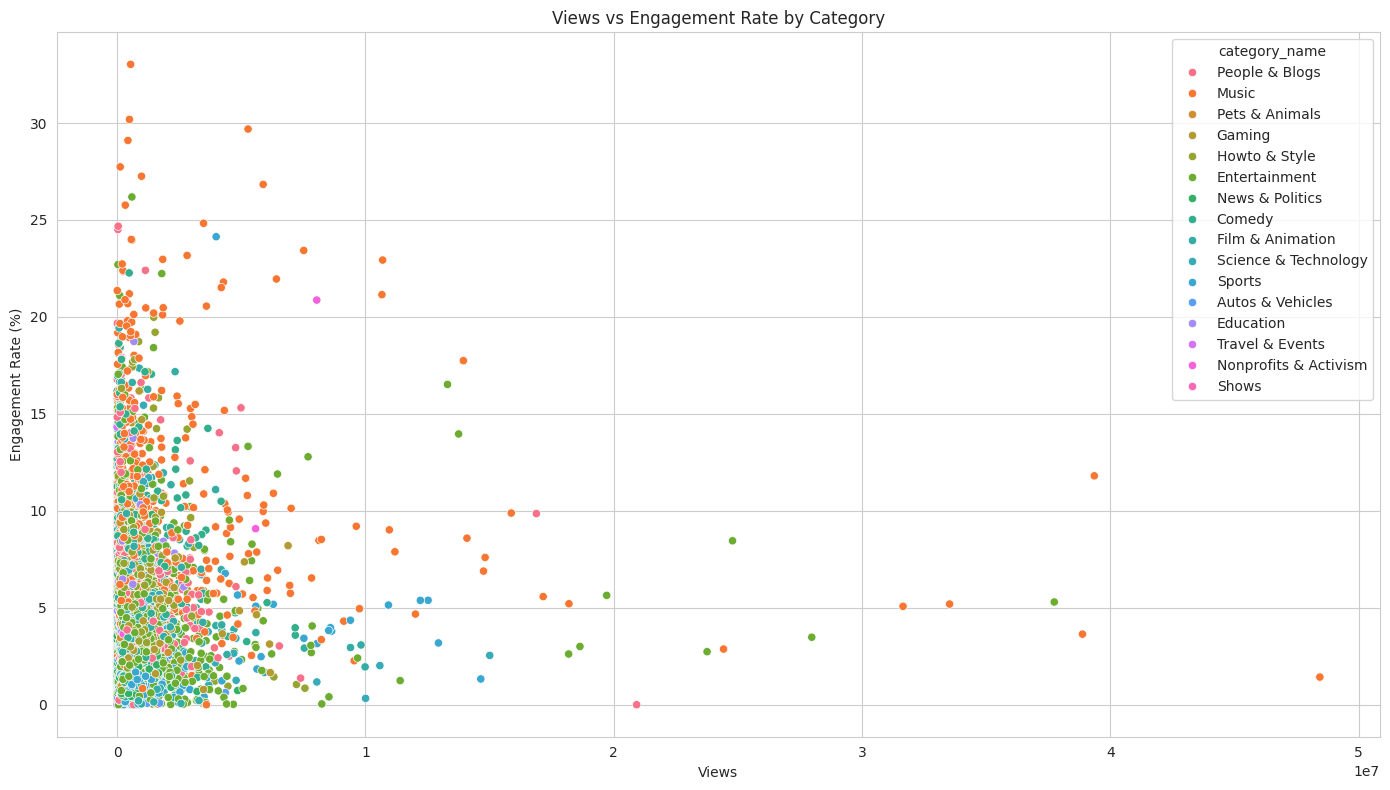

In [47]:
plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=videos_df,
    x='views',
    y='engagement_rate',
    hue='category_name'
)

plt.title('Views vs Engagement Rate by Category')

plt.xlabel('Views')

plt.ylabel('Engagement Rate (%)')

plt.tight_layout()

plt.show()

In [48]:
weekday_views = videos_df.groupby(
    'publish_weekday'
)['views'].mean().reset_index()

weekday_views = weekday_views.sort_values(
    by='views',
    ascending=False
)

print("=" * 60)
print("AVERAGE VIEWS BY PUBLISH WEEKDAY")
print("=" * 60)

print(weekday_views)

AVERAGE VIEWS BY PUBLISH WEEKDAY
  publish_weekday          views
0          Friday  894334.042025
3          Sunday  859492.576029
1          Monday  750340.857868
2        Saturday  726031.160878
5         Tuesday  722556.557022
4        Thursday  713014.400000
6       Wednesday  677738.515953


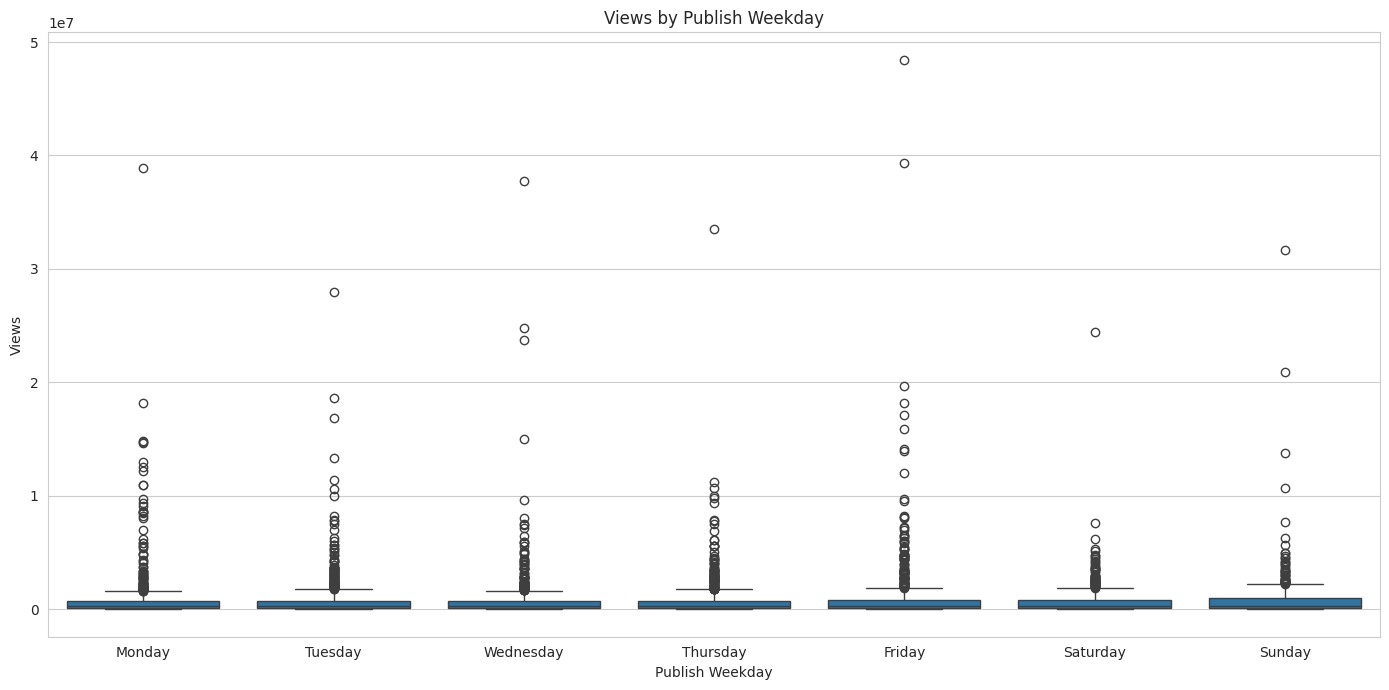

In [49]:
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=videos_df,
    x='publish_weekday',
    y='views',
    order=weekday_order
)

plt.title('Views by Publish Weekday')

plt.xlabel('Publish Weekday')

plt.ylabel('Views')

plt.tight_layout()

plt.show()

In [50]:
top_10_trending_videos = videos_df.sort_values(
    by='views',
    ascending=False
).head(10)

print("=" * 60)
print("TOP 10 TRENDING VIDEOS")
print("=" * 60)

print(
    top_10_trending_videos[
        [
            'title',
            'category_name',
            'views',
            'engagement_rate',
            'days_to_trend'
        ]
    ]
)

TOP 10 TRENDING VIDEOS
                                                   title  category_name  \
23824              Maluma - El Préstamo (Official Video)          Music   
35550                BTS (방탄소년단) 'FAKE LOVE' Official MV          Music   
28605                            TWICE What is Love? M/V          Music   
3200   Marvel Studios' Avengers: Infinity War Officia...  Entertainment   
70           Ed Sheeran - Perfect (Official Music Video)          Music   
33351  Childish Gambino - This Is America (Official V...          Music   
30750                      VENOM - Official Trailer (HD)  Entertainment   
4600   YouTube Rewind: The Shape of 2017 | #YouTubeRe...  Entertainment   
28624                              Drake - Nice For What          Music   
38161  Sanju | Official Trailer | Ranbir Kapoor | Raj...  Entertainment   

          views  engagement_rate  days_to_trend  
23824  48431654         1.425787              5  
35550  39349927        11.804553              0  
2

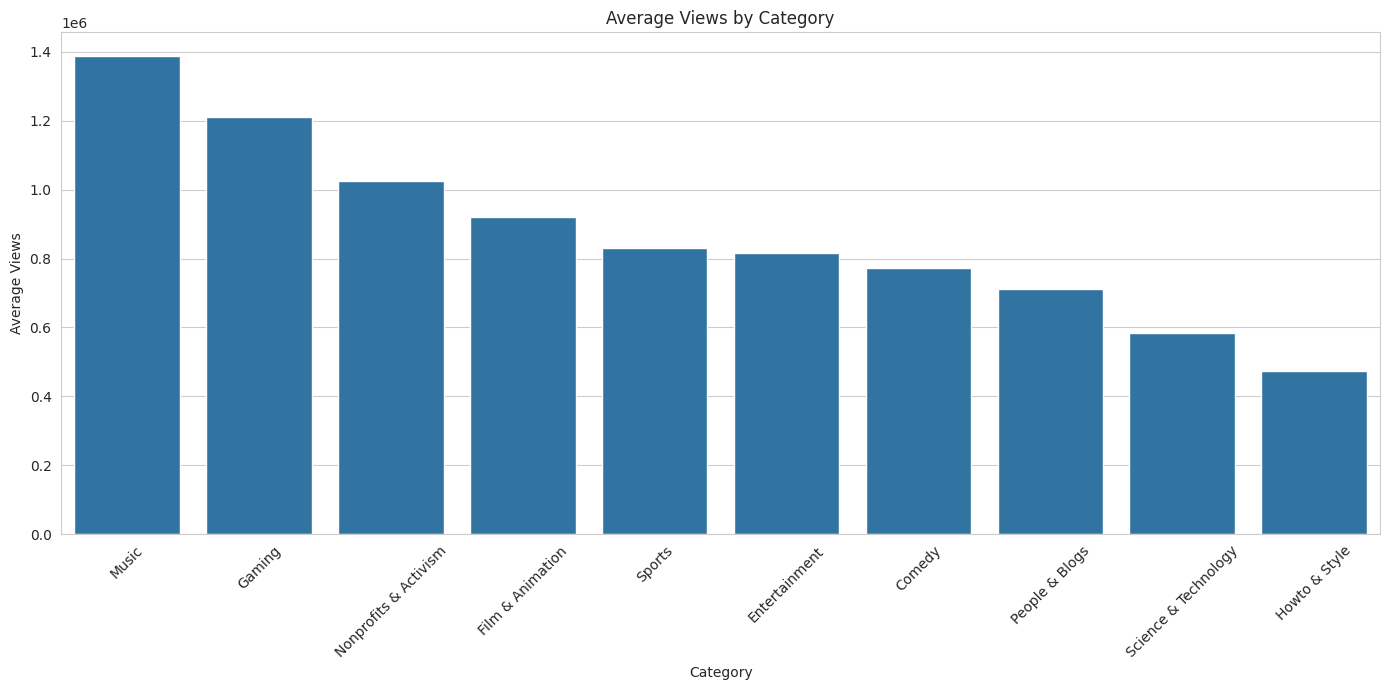

In [51]:
top_view_categories_chart = category_metrics.sort_values(
    by='avg_views',
    ascending=False
).head(10)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=top_view_categories_chart,
    x='category_name',
    y='avg_views'
)

plt.title('Average Views by Category')

plt.xlabel('Category')

plt.ylabel('Average Views')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

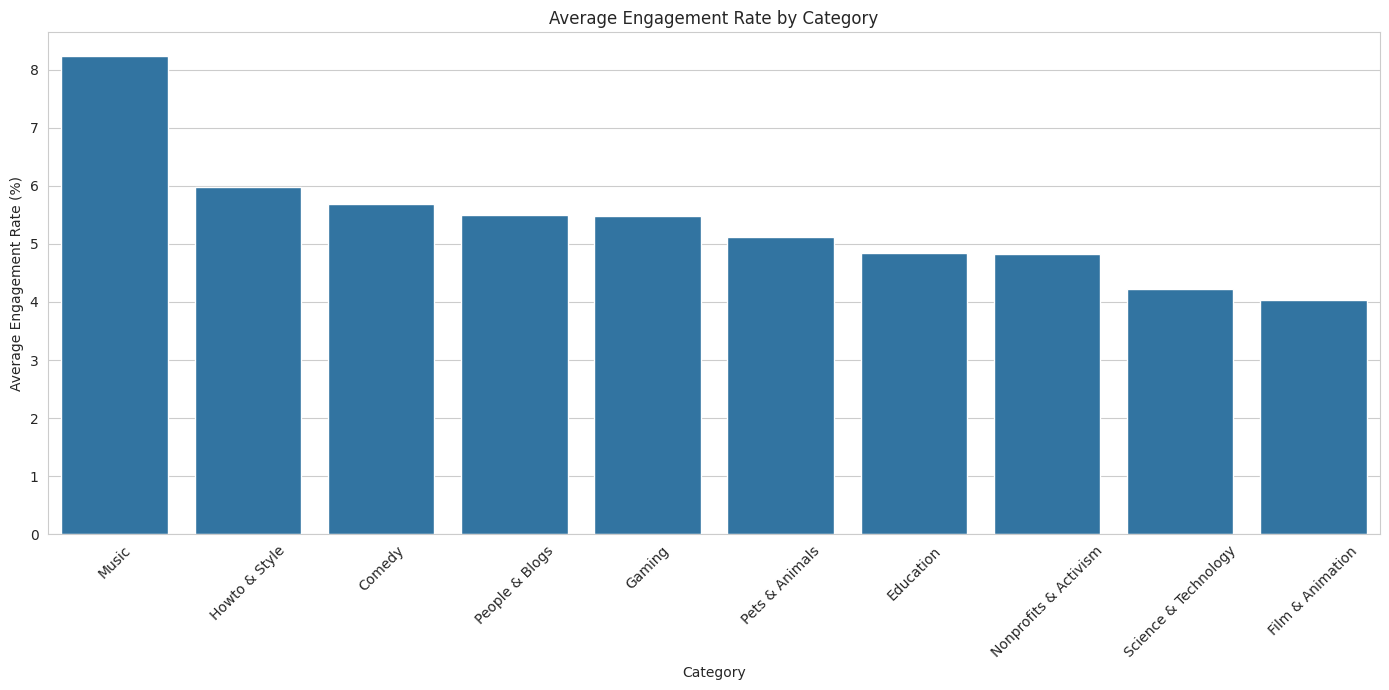

In [52]:
top_engagement_chart = category_metrics.sort_values(
    by='avg_engagement_rate',
    ascending=False
).head(10)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=top_engagement_chart,
    x='category_name',
    y='avg_engagement_rate'
)

plt.title('Average Engagement Rate by Category')

plt.xlabel('Category')

plt.ylabel('Average Engagement Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()